In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv(r"C:\Users\rpap9\OneDrive\Desktop\ML Project\Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
print("\nMissing values before any processing:")
print(df.isnull().sum())


Missing values before any processing:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


C:\Users\rpap9\AppData\Local\Temp\ipykernel_13696\2083360516.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='viridis')


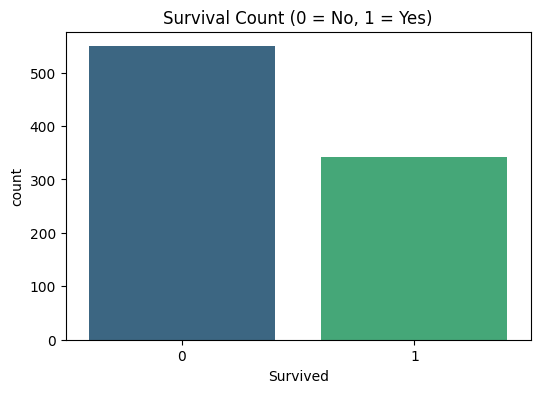


Survival Value Counts:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [6]:
# 1. Survival Rate
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='viridis')
plt.title('Survival Count (0 = No, 1 = Yes)')
plt.show()
print("\nSurvival Value Counts:")
print(df['Survived'].value_counts(normalize=True) * 100)

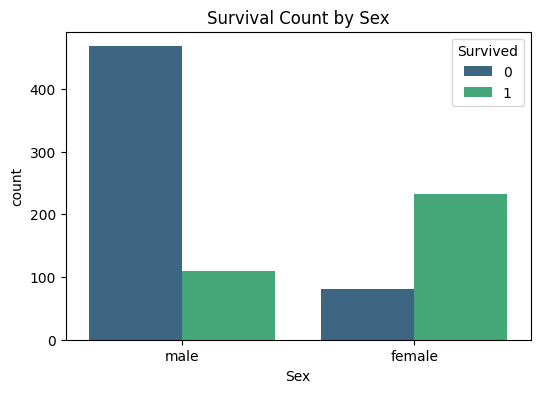


Survival Rate by Sex:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [7]:
# 2. Survival Rate by Sex
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', hue='Survived', data=df, palette='viridis')
plt.title('Survival Count by Sex')
plt.show()
print("\nSurvival Rate by Sex:")
print(df.groupby('Sex')['Survived'].mean() * 100)

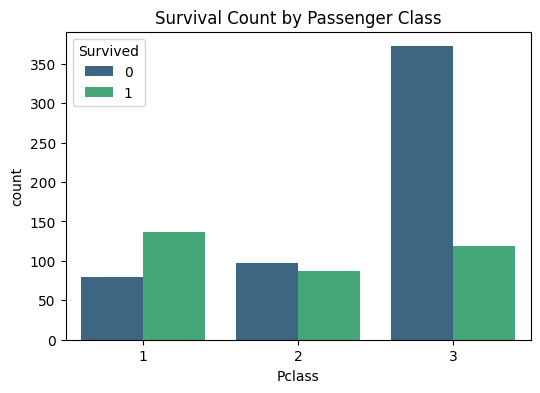


Survival Rate by Pclass:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [8]:
# 3. Survival Rate by Passenger Class (Pclass)
plt.figure(figsize=(6, 4))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='viridis')
plt.title('Survival Count by Passenger Class')
plt.show()
print("\nSurvival Rate by Pclass:")
print(df.groupby('Pclass')['Survived'].mean() * 100)

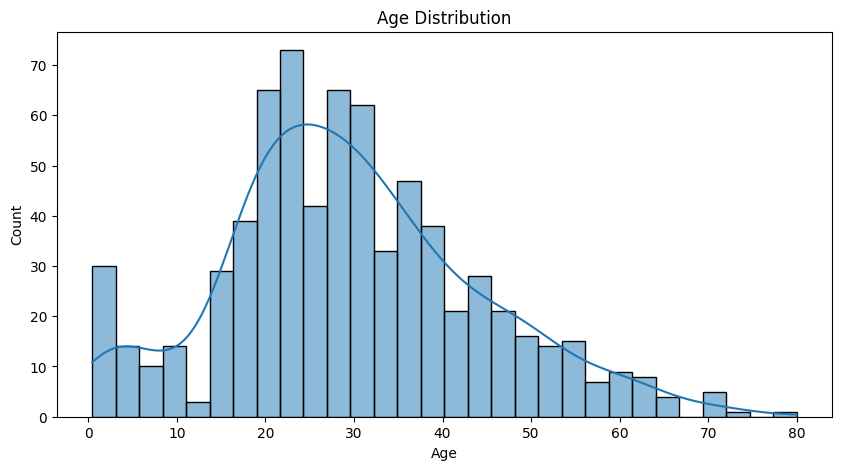

In [9]:
# 4. Age Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'].dropna(), kde=True, bins=30)
plt.title('Age Distribution')
plt.show()

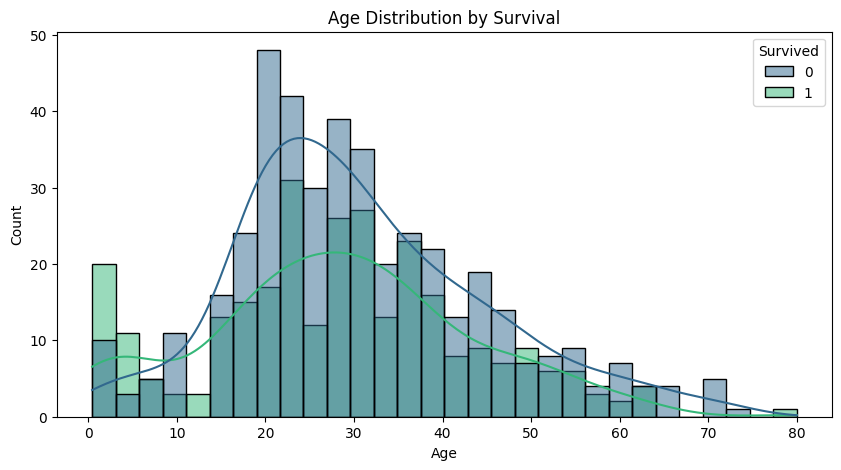

In [10]:
# 5. Age Distribution by Survival
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, palette='viridis')
plt.title('Age Distribution by Survival')
plt.show()

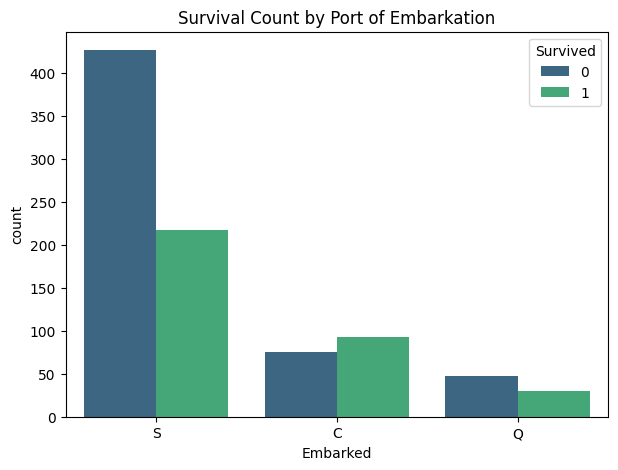


Survival Rate by Embarked:
Embarked
C           55.357143
Q           38.961039
S           33.695652
Unknown    100.000000
Name: Survived, dtype: float64


In [11]:
# 6. Survival Rate by Port of Embarkation (Embarked)
plt.figure(figsize=(7, 5))
sns.countplot(x='Embarked', hue='Survived', data=df, palette='viridis')
plt.title('Survival Count by Port of Embarkation')
plt.show()
print("\nSurvival Rate by Embarked:")
# Fill NaN temporarily for this calculation only, real handling comes later
print(df.groupby(df['Embarked'].fillna('Unknown'))['Survived'].mean() * 100)

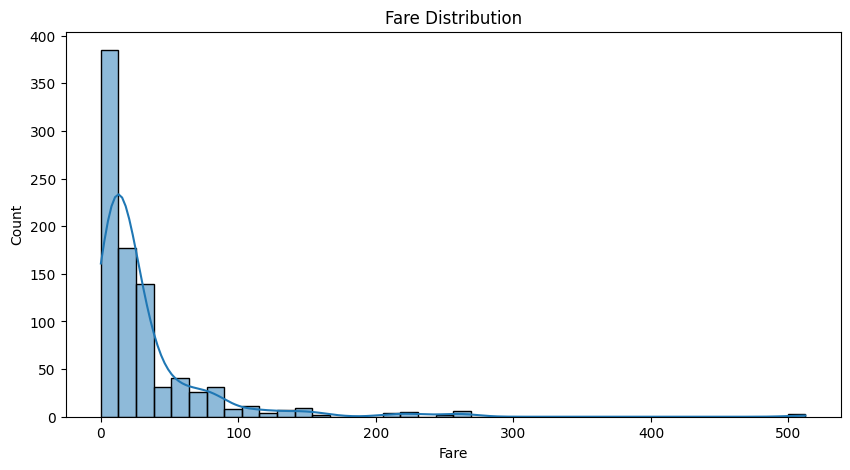

In [12]:
# 7. Fare Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Fare'], kde=True, bins=40)
plt.title('Fare Distribution')
plt.show()

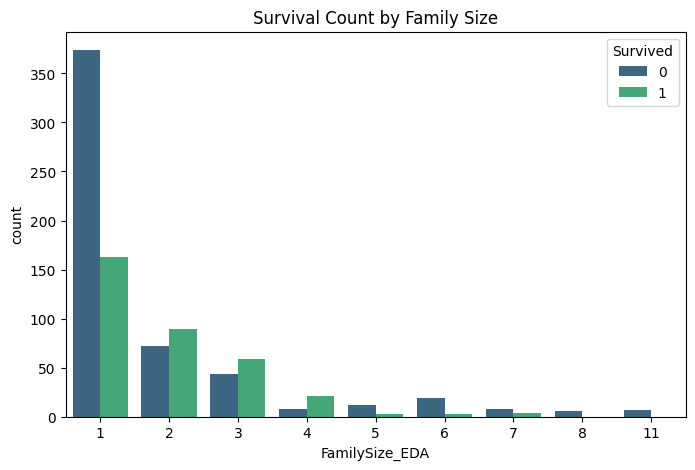


Survival Rate by Family Size:
FamilySize_EDA
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64


In [13]:
# 8. Family Size (SibSp + Parch)
# Create a temporary FamilySize column for EDA
df['FamilySize_EDA'] = df['SibSp'] + df['Parch'] + 1
plt.figure(figsize=(8, 5))
sns.countplot(x='FamilySize_EDA', hue='Survived', data=df, palette='viridis')
plt.title('Survival Count by Family Size')
plt.show()
print("\nSurvival Rate by Family Size:")
print(df.groupby('FamilySize_EDA')['Survived'].mean() * 100)
# Drop the temporary column
df = df.drop('FamilySize_EDA', axis=1)

In [14]:
print("\n--- Starting Data Preprocessing ---")
# 1. Handle Missing 'Age' values
median_age = df['Age'].median()
print(f"\nMedian Age: {median_age}")
df['Age'].fillna(median_age)
print("'Age' missing values imputed with median.")


--- Starting Data Preprocessing ---

Median Age: 28.0
'Age' missing values imputed with median.


In [15]:
# 2. Handle Missing 'Embarked' values
mode_embarked = df['Embarked'].mode()[0]
print(f"Most frequent Embarked Port: {mode_embarked}")
df['Embarked'].fillna(mode_embarked)
print("'Embarked' missing values imputed with mode.")

Most frequent Embarked Port: S
'Embarked' missing values imputed with mode.


In [22]:
# 3. Drop 'Cabin' column BEFORE creating dummies or dropping others
# Ensure 'Cabin' exists before dropping
if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)
    print("'Cabin' column dropped.")
else:
    print("'Cabin' column already removed or does not exist.")

'Cabin' column dropped.


In [17]:
# 4. Convert 'Sex' to Numerical (0/1) BEFORE dropping other columns
# Ensure 'Sex' exists and has expected values
if 'Sex' in df.columns:
    print("\nOriginal 'Sex' value counts:")
    print(df['Sex'].value_counts())
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1}).astype(int) # Map and ensure integer type
    print("Converted 'Sex' to numerical (0=male, 1=female).")
else:
     print("'Sex' column not found. Check previous steps.")


Original 'Sex' value counts:
Sex
male      577
female    314
Name: count, dtype: int64
Converted 'Sex' to numerical (0=male, 1=female).


In [18]:
# 5. Convert 'Embarked' using One-Hot Encoding
# Ensure 'Embarked' exists before getting dummies
if 'Embarked' in df.columns:
    df = pd.get_dummies(df, columns=['Embarked'], drop_first=True, prefix='Embarked', dtype=int) # Use dtype=int for 0/1
    print("Converted 'Embarked' to numerical using One-Hot Encoding.")
else:
    print("'Embarked' column not found or already processed.")

Converted 'Embarked' to numerical using One-Hot Encoding.


In [19]:
# 6. Feature Engineering: Create 'FamilySize' and Drop Originals
# Ensure 'SibSp' and 'Parch' exist
if 'SibSp' in df.columns and 'Parch' in df.columns:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    # Drop the original columns AFTER creating FamilySize
    df.drop(['SibSp', 'Parch'], axis=1, inplace=True)
    print("Created 'FamilySize' feature and dropped 'SibSp', 'Parch'.")
else:
    print("'SibSp' or 'Parch' columns not found. Cannot create 'FamilySize'.")

Created 'FamilySize' feature and dropped 'SibSp', 'Parch'.


In [20]:
# 7. Drop unnecessary columns LAST (PassengerId, Name, Ticket)
columns_to_drop = ['PassengerId', 'Name', 'Ticket']
# Check if columns exist before dropping
cols_exist_to_drop = [col for col in columns_to_drop if col in df.columns]
if cols_exist_to_drop:
    df.drop(cols_exist_to_drop, axis=1, inplace=True)
    print(f"Dropped unnecessary columns: {cols_exist_to_drop}")
else:
    print(f"Columns {columns_to_drop} already removed or do not exist.")


print("\n--- Preprocessing Completed ---")

Dropped unnecessary columns: ['PassengerId', 'Name', 'Ticket']

--- Preprocessing Completed ---


In [23]:
print("\n--- Verifying Data Types Before Splitting ---")
print("DataFrame Info after Preprocessing:")
df.info()
print("\nDataTypes after Preprocessing:")
print(df.dtypes)
print("\nFirst 5 rows after Preprocessing:")
print(df.head())

# Check if any object columns remain that shouldn't be there
object_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nRemaining 'object' type columns: {object_cols}")

# Assert that all columns intended for the model are numeric
potential_x_cols = [col for col in df.columns if col != 'Survived']
are_all_numeric = all(pd.api.types.is_numeric_dtype(df[col]) for col in potential_x_cols)

if not are_all_numeric:
    print("\nERROR: Found non-numeric columns intended for the model!")
    for col in potential_x_cols:
        if not pd.api.types.is_numeric_dtype(df[col]):
            print(f"  - Column '{col}' is NOT numeric (dtype: {df[col].dtype})")
else:
    print("\nSUCCESS: All columns for features (X) appear to be numeric.")


--- Verifying Data Types Before Splitting ---
DataFrame Info after Preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         714 non-null    float64
 4   Fare        891 non-null    float64
 5   Embarked_Q  891 non-null    int64  
 6   Embarked_S  891 non-null    int64  
 7   FamilySize  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB

DataTypes after Preprocessing:
Survived        int64
Pclass          int64
Sex             int64
Age           float64
Fare          float64
Embarked_Q      int64
Embarked_S      int64
FamilySize      int64
dtype: object

First 5 rows after Preprocessing:
   Survived  Pclass  Sex   Age     Fare  Embarked_Q  Embarked_S  FamilySize
0         0       3

In [24]:
print("\n--- Preparing Data for Modeling ---")

# Separate features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("\nFeatures columns:", X.columns.tolist()) # Verify columns in X

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set shape: X_test={X_test.shape}, y_test={y_test.shape}")
print("\nSplit data into Training and Testing sets.")


--- Preparing Data for Modeling ---
Features (X) shape: (891, 7)
Target (y) shape: (891,)

Features columns: ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked_Q', 'Embarked_S', 'FamilySize']

Training set shape: X_train=(712, 7), y_train=(712,)
Testing set shape: X_test=(179, 7), y_test=(179,)

Split data into Training and Testing sets.



--- Training Initial Decision Tree Model ---
Initial Decision Tree model trained successfully.

--- Initial Model Evaluation ---
Accuracy: 0.7765

Confusion Matrix:
[[91 19]
 [21 48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       110
           1       0.72      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



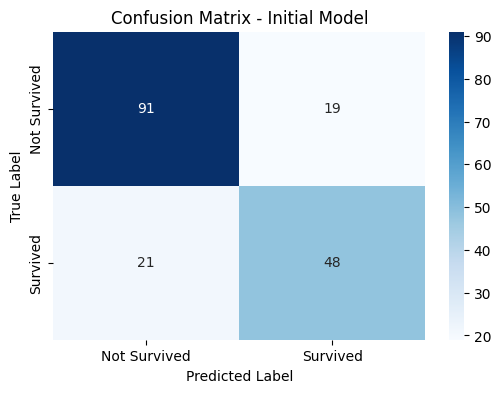

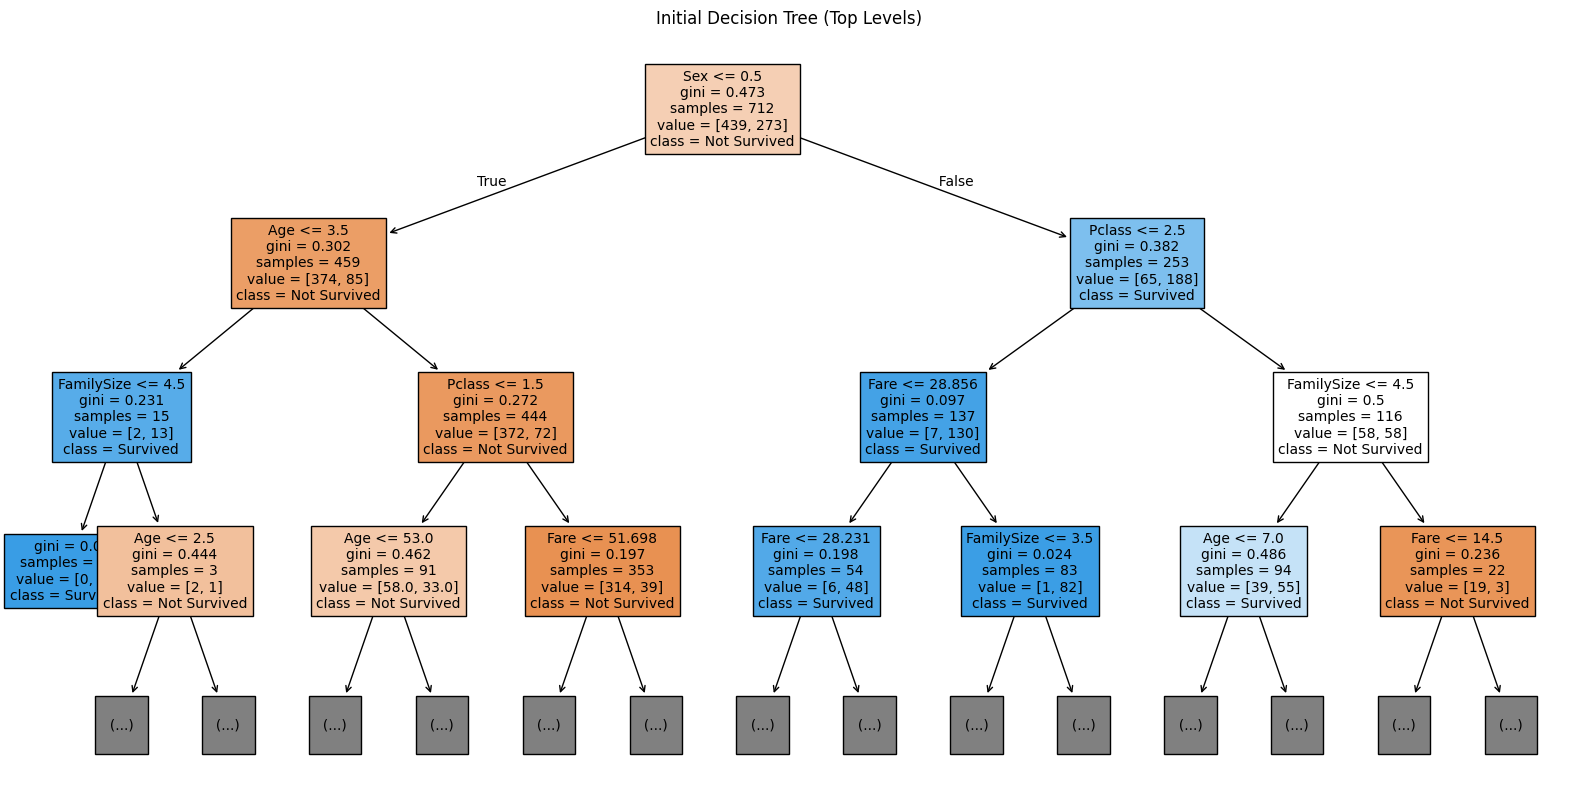

NOTE: The initial tree might be overfitting (deep and complex).


In [25]:
print("\n--- Training Initial Decision Tree Model ---")

# Initialize the Decision Tree Classifier
initial_dt = DecisionTreeClassifier(random_state=42)

# Train the model <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# THIS LINE SHOULD NOW WORK if the checks above passed
initial_dt.fit(X_train, y_train)

print("Initial Decision Tree model trained successfully.")

# Make predictions on the test set
y_pred_initial = initial_dt.predict(X_test)

# Evaluate the initial model
accuracy_initial = accuracy_score(y_test, y_pred_initial)
cm_initial = confusion_matrix(y_test, y_pred_initial)
cr_initial = classification_report(y_test, y_pred_initial)

print("\n--- Initial Model Evaluation ---")
print(f"Accuracy: {accuracy_initial:.4f}")
print("\nConfusion Matrix:")
print(cm_initial)
print("\nClassification Report:")
print(cr_initial)

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_initial, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Initial Model')
plt.show()

# Visualize the initial tree
plt.figure(figsize=(20, 10))
plot_tree(initial_dt,
          filled=True,
          feature_names=X.columns,
          class_names=['Not Survived', 'Survived'],
          max_depth=3, # Limit depth for readability
          fontsize=10)
plt.title("Initial Decision Tree (Top Levels)")
plt.show()
print("NOTE: The initial tree might be overfitting (deep and complex).")

In [27]:
# --- Hyperparameter Tuning using GridSearchCV ---

print("\n--- Hyperparameter Tuning using GridSearchCV ---")

# Define the parameter grid to search
# These are common parameters to tune for Decision Trees
param_grid = {
    'criterion': ['gini', 'entropy'],           # Function to measure the quality of a split
    'max_depth': [None, 3, 5, 7, 10, 15],       # Maximum depth of the tree (None means nodes expand until pure or min_samples)
    'min_samples_split': [2, 5, 10, 15, 20],    # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 3, 5, 7, 10],       # Minimum number of samples required to be at a leaf node
    'max_features': [None, 'sqrt', 'log2']      # Number of features to consider when looking for the best split
                                                # None = all features, 'sqrt' = sqrt(n_features), 'log2' = log2(n_features)
}

# Initialize the Decision Tree Classifier (base estimator)
dt_base = DecisionTreeClassifier(random_state=42) # Keep random_state for consistency

grid_search = GridSearchCV(estimator=dt_base,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=1)

# Fit GridSearchCV to the training data
# This will train multiple Decision Trees with different parameter combinations
print("Starting Grid Search... (This may take a few moments)")
grid_search.fit(X_train, y_train) # Use the training data (X_train, y_train)

print("Grid Search completed.")

# Get the best parameters found by the search
best_params = grid_search.best_params_
# Get the best cross-validation score achieved with these parameters
best_score = grid_search.best_score_

print(f"\nBest Parameters found by GridSearchCV: {best_params}")
print(f"Best Cross-Validation Accuracy during search: {best_score:.4f}")

best_dt = grid_search.best_estimator_

print("Best Decision Tree model obtained from GridSearchCV.")


--- Hyperparameter Tuning using GridSearchCV ---
Starting Grid Search... (This may take a few moments)
Fitting 5 folds for each of 900 candidates, totalling 4500 fits
Grid Search completed.

Best Parameters found by GridSearchCV: {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 15}
Best Cross-Validation Accuracy during search: 0.8133
Best Decision Tree model obtained from GridSearchCV.



--- Evaluating Tuned Decision Tree Model ---

Tuned Model Test Accuracy: 0.7654

Tuned Model Confusion Matrix:
[[89 21]
 [21 48]]

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       110
           1       0.70      0.70      0.70        69

    accuracy                           0.77       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.77      0.77      0.77       179



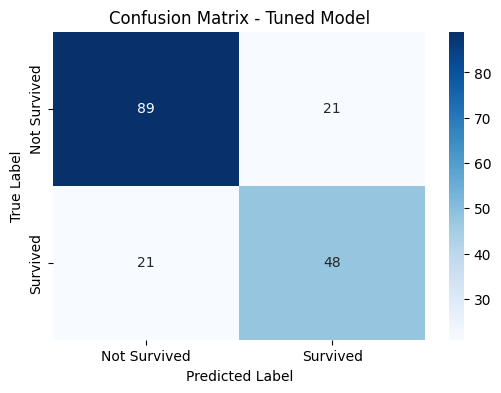

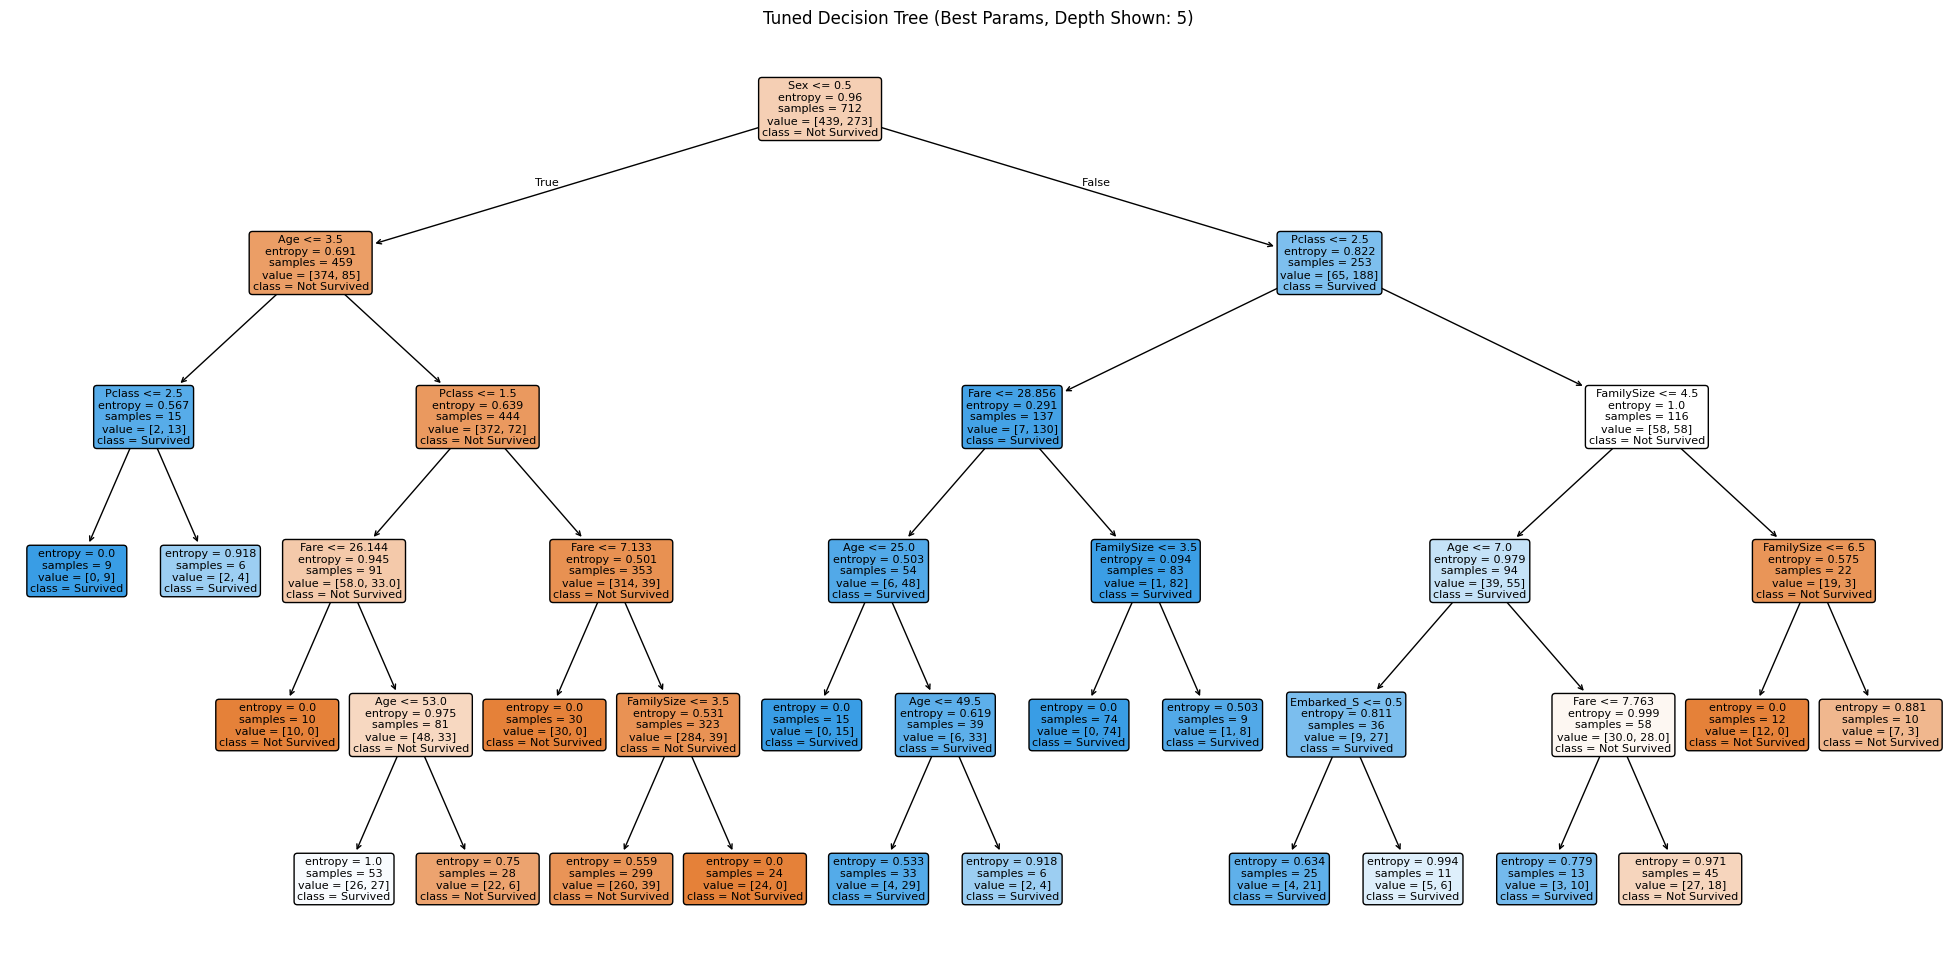

In [28]:
# --- Evaluate the Tuned Decision Tree Model ---

print("\n--- Evaluating Tuned Decision Tree Model ---")

# Make predictions on the TEST set using the best model found by GridSearchCV
y_pred_tuned = best_dt.predict(X_test)

# Evaluate the performance of the tuned model on the unseen test data
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
cr_tuned = classification_report(y_test, y_pred_tuned)

print(f"\nTuned Model Test Accuracy: {accuracy_tuned:.4f}")
print("\nTuned Model Confusion Matrix:")
print(cm_tuned)
print("\nTuned Model Classification Report:")
print(cr_tuned)

# Visualize the Tuned Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Tuned Model')
plt.show()


vis_depth = best_dt.get_params()['max_depth'] # Get the actual depth used by the best model
if vis_depth is None: # Handle case where max_depth is None (fully grown)
    print("\nTuned tree has no max_depth limit, visualizing top 5 levels for clarity.")
    vis_depth = 5 # Set a reasonable limit for visualization if it's fully grown
elif vis_depth > 7: # Limit visualization if the optimal depth is very large
     print(f"\nTuned tree max_depth is {vis_depth}, visualizing top 7 levels for clarity.")
     vis_depth = 7

plt.figure(figsize=(25, 12)) # May need adjustment based on tree complexity
plot_tree(best_dt,
          filled=True,
          feature_names=X.columns,
          class_names=['Not Survived', 'Survived'],
          max_depth=vis_depth, # Visualize up to the chosen depth
          fontsize=8,
          rounded=True)
plt.title(f"Tuned Decision Tree (Best Params, Depth Shown: {vis_depth})")
plt.show()


--- Feature Importances from Tuned Model ---
Feature importances ranked:
      Feature  Importance
1         Sex    0.495043
0      Pclass    0.237474
2         Age    0.121300
6  FamilySize    0.072076
3        Fare    0.066569
5  Embarked_S    0.007538
4  Embarked_Q    0.000000


C:\Users\rpap9\AppData\Local\Temp\ipykernel_13696\765418052.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


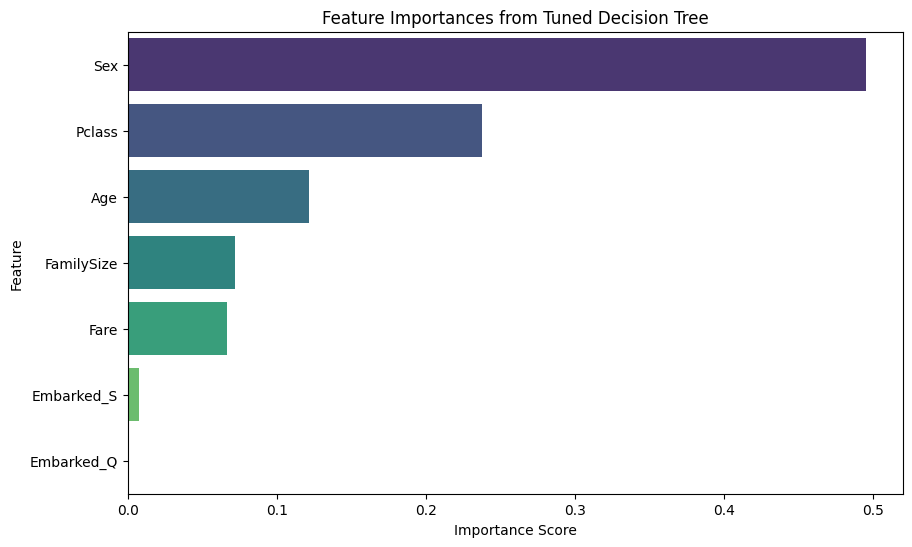


--- Process Completed ---


In [29]:
# --- Feature Importance ---

print("\n--- Feature Importances from Tuned Model ---")

# Extract feature importances from the best_dt model
importances = best_dt.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature importances ranked:")
print(feature_importance_df)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importances from Tuned Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print("\n--- Process Completed ---")